## 02. Neural Network Classification with PyTorch

Classification is a problem of predicting whether something is under one thing or another(there can be multiple things as the options)

##1. Make classification data and get it ready

In [ ]:
import sklearn
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)

In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of X : {X[:5]}")
print(f"First 5 samples of y : {y[:5]}")

First 5 samples of X : [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y : [1 1 1 1 0]


In [ ]:
# Make DataFrame of circle data with pandas
import pandas as pd
circles = pd.DataFrame({"X1" : X[:, 0],
                        "X2" : X[:, 1],
                        "label" : y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


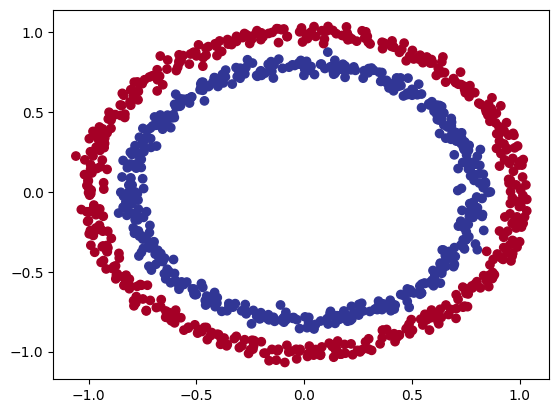

In [ ]:
# Visualise, visualise, visualise
import matplotlib.pyplot as plt
plt.scatter(x = X[:, 0],
            y = X[:, 1],
            c = y, #color it with labels
            cmap = plt.cm.RdYlBu);

**Note** : The data we're working with is often referred to as a toy dataset, a dataset
that is small enough to experiment but still sizeable enough to practice the
fundamentals.

### 1.1 Check input and output shapes

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shape for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shape for one sample of X: (2,) and the same for y: ()


## 1.2 Turn data into tensors and create train and test splits

In [ ]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [ ]:
# Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X.dtype, X[:5], y[:5], y.dtype

(torch.float32,
 tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]),
 torch.float32)

In [ ]:
# Split data into tranining and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Let's build a model to classify our blue and red dots

To do so, we want to:
1. Setup device agnostic code so our code will run on GPU if there's one
2. Construct a model (by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a training and testing loop

In [ ]:
import torch
from torch import nn

# Device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Constructing a model with 2 nn.Linear layers
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    # Create 2 linear layers capable of handling shape of our data
    self.layer_1 = nn.Linear(in_features = 2, out_features = 5)
    self.layer_2 = nn.Linear(in_features = 5, out_features = 1)

  # 3. Define a forward method that outlines the forward pass
  def forward(self, X):
    return self.layer_2(self.layer_1(X))

# 4. Instantiate an instance of our model class and send it to target device
model_0 = CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [ ]:
# Lets's replicate the model above using nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features = 2, out_features = 5),
    nn.Linear(in_features = 5, out_features = 1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [ ]:
# Make some prediictions with the model
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions : {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"First 10 labels:\n{y_test[:10]}")

Length of predictions : 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0')
First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function or optimizer

Which loss function or optimizer should you use?

Again.. this is problem specific

Regression - MAE or MSE

Classification - Binary Cross Entropy or Categorical Cross Entropy

Loss function - Measures how *wrong* our model's predictions are

Optimizers - SGD and Adam (two most common ones)

* For the loss function we're going to use 'torch.nn.BCEWithLogitsLoss()',
for more - https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a/

For different optimizers see 'torch.optim'

**BCELoss()** - requires inputs to have gone through the sigmoid activation function prior to input to BCELoss()

**BCEWithLogitsLoss()** - This version is more numerically stable than using a plain Sigmoid followed by a BCELoss as, by combining the operations into one layer, we take advantage of the log-sum-exp trick for numerical stability.

In [ ]:
# Setup the loss function
loss_fn = nn.BCEWithLogitsLoss() #built in sigmoid layer and BCELoss in a single class

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)

In [ ]:
# Calculate accuracy - out of 100 examples, what precentage does our model get right?
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

## 3. Train model

Build training loop

1. Forward Pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backprop)
5. Optimizer step (gradient descent)


### 3.1 Going from raw logits -> predicting probablities -> prediction labels

Our model outputs -> raw **logits**

Raw **logits** -> sigmoid/softmax -> probabilities -> (round/argmax) -> prediction labels

In [ ]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use sigmoid on logits -> probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [ ]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0')

# 3.2 Building a training and testing loop

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set Epochs
epochs = 1000

# Put data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop

for epoch in range(epochs):
  # Training
  model_0.train()

  # 1. Forward Pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) #pred labels

  # 2. Calculate Loss and Accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss Backward (backprop)
  loss.backward()

  # 5. Optimizer step (GD)
  optimizer.step()

  ### Testing
  model_0.eval()

  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

  # Calculate the test loss
  test_loss = loss_fn(test_logits, y_test)
  test_acc = accuracy_fn(y_test, test_pred)

  # Print out what's happenin'
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69796, Acc: 51.88% | Test Loss: 0.69440, Test Acc: 58.00%
Epoch: 100 | Loss: 0.69331, Acc: 49.25% | Test Loss: 0.69271, Test Acc: 53.00%
Epoch: 200 | Loss: 0.69310, Acc: 50.88% | Test Loss: 0.69336, Test Acc: 49.00%
Epoch: 300 | Loss: 0.69304, Acc: 51.12% | Test Loss: 0.69376, Test Acc: 46.50%
Epoch: 400 | Loss: 0.69301, Acc: 51.25% | Test Loss: 0.69403, Test Acc: 47.50%
Epoch: 500 | Loss: 0.69299, Acc: 50.88% | Test Loss: 0.69423, Test Acc: 47.00%
Epoch: 600 | Loss: 0.69299, Acc: 51.25% | Test Loss: 0.69436, Test Acc: 46.50%
Epoch: 700 | Loss: 0.69298, Acc: 51.25% | Test Loss: 0.69446, Test Acc: 46.00%
Epoch: 800 | Loss: 0.69298, Acc: 51.50% | Test Loss: 0.69453, Test Acc: 45.50%
Epoch: 900 | Loss: 0.69298, Acc: 51.38% | Test Loss: 0.69458, Test Acc: 45.00%


## 4. Make predictions and evaluate the model

From the metric it looks like our model isn't learning anything...

So to inspect it let's make some predictions and make them visual!

In other words, "Visualize, Visualize, Visualize!"

To do so, we're going to import a function called 'plot_decision_boundary()' -
https://madewithml.com/courses/foundations/neural-networks/
(imp)

In [ ]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("Already exits, skipping download")
else:
  print("Downloading helper_funtions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_decision_boundary, plot_predictions

Already exits, skipping download


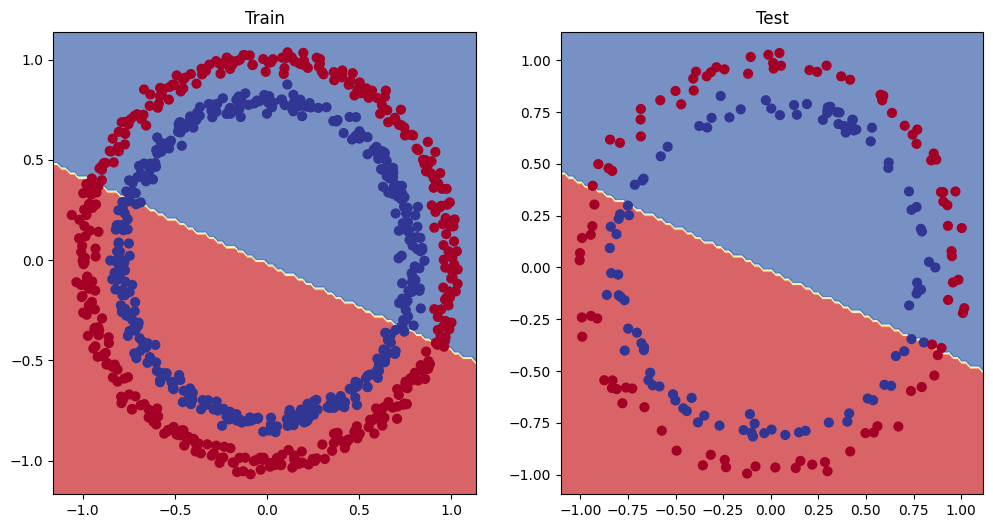

In [ ]:
# Plot decision boundary of the model
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


## 5. Improving a model (from a model perspective)

* Add more layers - Give the model more chances to learn about patterns in the data
* Add more hidden units - more parameters potentially more chances to learn patterns
* Fit for longer
* Change the Actiavtion Functions
* Change the learningn rate
* Change the Loss

These options are all from a model's perspective because they deal directly with the model rather than the data

And because these options are all values we (as ML engineers and data scientists) can change, they are hyperparameters.

Let's try and improve our model by:
* Adding more hidden units: 5->10
* Increase the number of layers: 2->3
* Increase the number of epochs: 100 -> 1000

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward(self, X):
    return self.layer_3(self.layer_2(self.layer_1(X)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(),
                             lr = 0.1)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Training and evaluation loop
epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)

  optimizer.zero_grad

  loss.backward()

  optimizer.step()

  ### Testing
  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396, Acc: 50.88% | Test Loss: 0.69261, Test Acc: 51.00%
Epoch: 10 | Loss: 0.69315, Acc: 41.62% | Test Loss: 0.69382, Test Acc: 40.50%
Epoch: 20 | Loss: 0.69343, Acc: 51.00% | Test Loss: 0.69720, Test Acc: 48.00%
Epoch: 30 | Loss: 0.69367, Acc: 51.12% | Test Loss: 0.69816, Test Acc: 47.50%
Epoch: 40 | Loss: 0.69314, Acc: 50.88% | Test Loss: 0.69589, Test Acc: 47.00%
Epoch: 50 | Loss: 0.69339, Acc: 50.88% | Test Loss: 0.69383, Test Acc: 54.00%
Epoch: 60 | Loss: 0.69351, Acc: 48.50% | Test Loss: 0.69264, Test Acc: 50.00%
Epoch: 70 | Loss: 0.69335, Acc: 49.00% | Test Loss: 0.69258, Test Acc: 53.00%
Epoch: 80 | Loss: 0.69322, Acc: 51.62% | Test Loss: 0.69358, Test Acc: 52.00%
Epoch: 90 | Loss: 0.69307, Acc: 49.12% | Test Loss: 0.69495, Test Acc: 47.50%


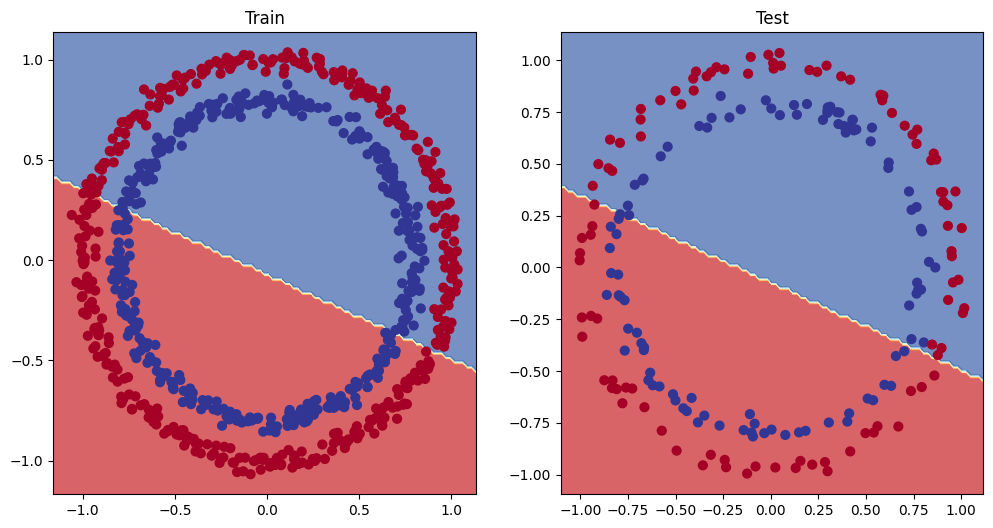

In [ ]:
# Plot the decision boundary
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if model can fit a straight line

One way to troubleshoot to a larger problem is to test out a smaller problem

In [ ]:
# Create some data (same as notebook 01)
w = 0.7
b = 0.3

start = 0
end = 1
step = 0.01
X_regression = torch.arange(start, end, step).unsqueeze(dim = 1)
y_regression = w * X_regression + b

# Check the data
print(len(X_regression), len(y_regression))
X_regression[:5], y_regression[:5]

100 100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# Create train and test splits
split = int( 0.8 * len(X_regression))

X_train_r, y_train_r = X_regression[:split], y_regression[:split]
X_test_r, y_test_r = X_regression[split:], y_regression[split:]

# Check the shapes
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

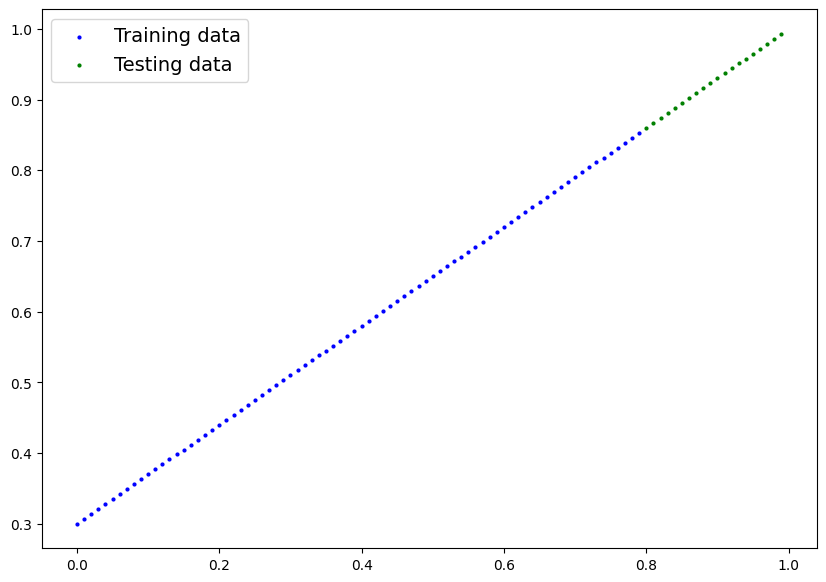

In [ ]:
plot_predictions(train_data = X_train_r,
                 train_labels = y_train_r,
                 test_data = X_test_r,
                 test_labels = y_test_r,
                 predictions = None)

### 5.2 Adjusting 'model_1' to fit a straight line

In [ ]:
# Same architecture as model_1 (but using nn.Sequential)

model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                            lr = 0.01)

In [ ]:
###Training
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train_r, y_train_r = X_train_r.to(device), y_train_r.to(device)
X_test_r, y_test_r = X_test_r.to(device), y_test_r.to(device)

for epoch in range(epochs):
  model_2.train()
  y_pred = model_2(X_train_r)
  loss = loss_fn(y_pred, y_train_r)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    y_test_pred = model_2(X_test_r)
    test_loss = loss_fn(y_test_pred, y_test_r)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test Loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test Loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test Loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test Loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test Loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test Loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test Loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test Loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test Loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test Loss: 0.00360


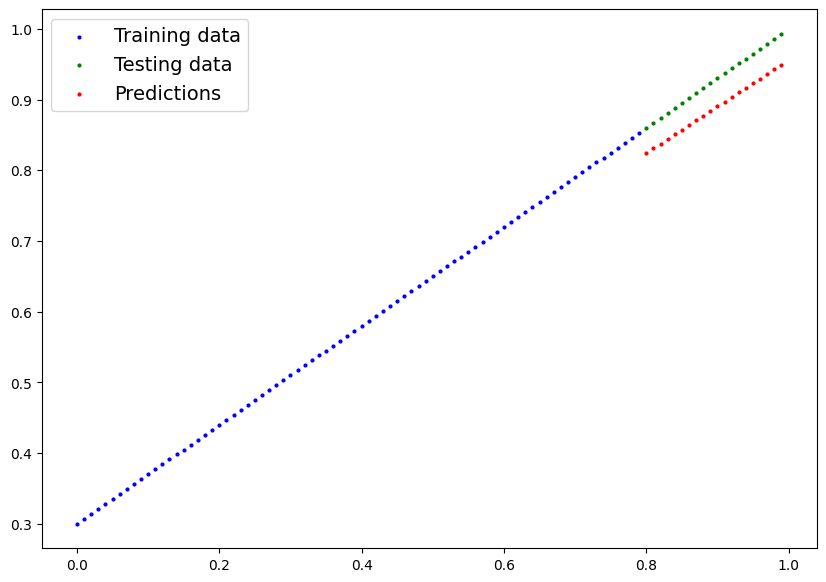

In [ ]:
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test_r)

plot_predictions(train_data = X_train_r.cpu(),
                 train_labels = y_train_r.cpu(),
                 test_data = X_test_r.cpu(),
                 test_labels = y_test_r.cpu(),
                 predictions = y_preds.cpu())

## 6. The missing piece : Non-Linearity
"What patterns could you draw if you were given an infinite amount of a straight and non - straight lines?"

Or in ML terms, an infinte (but really it is finite) of linear and non - linear funtions?

Tensorflow NN playground - https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.01&regularizationRate=0&noise=0&networkShape=4,2&seed=0.95203&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false

### 6.1 Recreating non-linear data (red and blue circles)

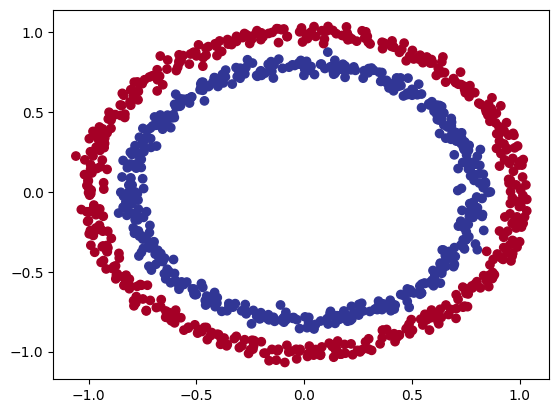

In [ ]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n = 1000

X, y = make_circles(n,
                    noise = 0.03,
                    random_state = 42)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.RdYlBu);

In [ ]:
# Convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non - linearity

* Linear = straight lines
* Non - linear = non - straight lines

Artificial NN are combination of linear and non-linear activation functions

In [ ]:
# Build a model with non-linear activation functions
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU() # relu - non linear activation function

  def forward(self, X):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
## Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params= model_3.parameters(),
                            lr = 0.1)

### 6.3 Training a model with non-linearity

In [ ]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#epochs
epochs = 2000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_3.train()

  y_logits = model_3(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_preds)

  if epoch % 200 == 0:
    print(f"Epoch : {epoch} | Loss : {loss:.4f} | Train_acc = {acc:.2f}% | Test_Loss = {test_loss:.4f} | Test_acc = {test_acc:.2f}%")

Epoch : 0 | Loss : 0.6929 | Train_acc = 50.00% | Test_Loss = 0.6932 | Test_acc = 50.00%
Epoch : 200 | Loss : 0.6898 | Train_acc = 53.37% | Test_Loss = 0.6894 | Test_acc = 55.00%
Epoch : 400 | Loss : 0.6852 | Train_acc = 52.75% | Test_Loss = 0.6841 | Test_acc = 56.50%
Epoch : 600 | Loss : 0.6751 | Train_acc = 54.50% | Test_Loss = 0.6729 | Test_acc = 56.00%
Epoch : 800 | Loss : 0.6516 | Train_acc = 64.00% | Test_Loss = 0.6476 | Test_acc = 67.50%
Epoch : 1000 | Loss : 0.5682 | Train_acc = 87.75% | Test_Loss = 0.5738 | Test_acc = 86.50%
Epoch : 1200 | Loss : 0.3706 | Train_acc = 97.75% | Test_Loss = 0.4059 | Test_acc = 92.00%
Epoch : 1400 | Loss : 0.1718 | Train_acc = 99.50% | Test_Loss = 0.2211 | Test_acc = 97.50%
Epoch : 1600 | Loss : 0.0912 | Train_acc = 99.88% | Test_Loss = 0.1274 | Test_acc = 99.50%
Epoch : 1800 | Loss : 0.0577 | Train_acc = 99.88% | Test_Loss = 0.0867 | Test_acc = 99.50%


### 6.4 Evaluating a model trained with non linear activation functions

In [ ]:
# Make predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

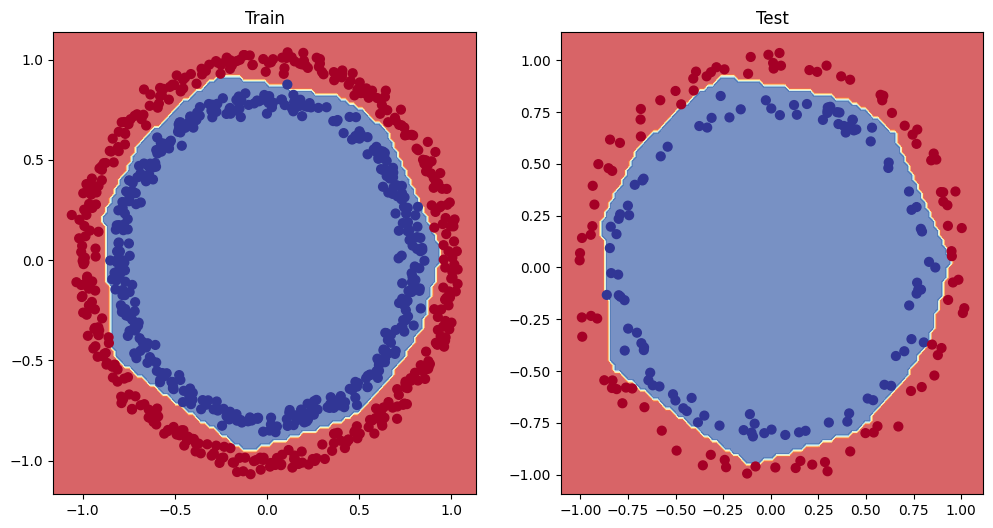

In [ ]:
# Plot decision boundary
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

## 7. Replicating non linear activation functions

Neural Networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

And these tools are linear and non linear functions.

In [ ]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype = torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

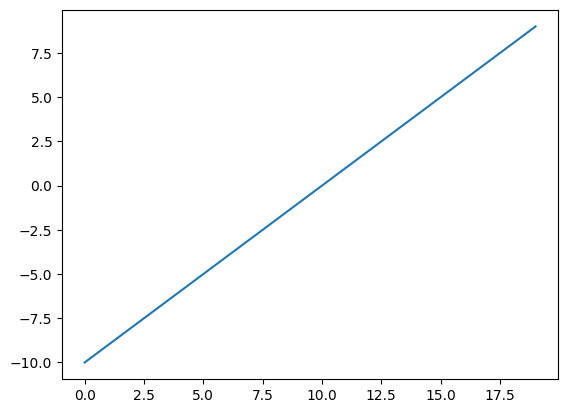

In [ ]:
# Visualize this data
plt.plot(A);

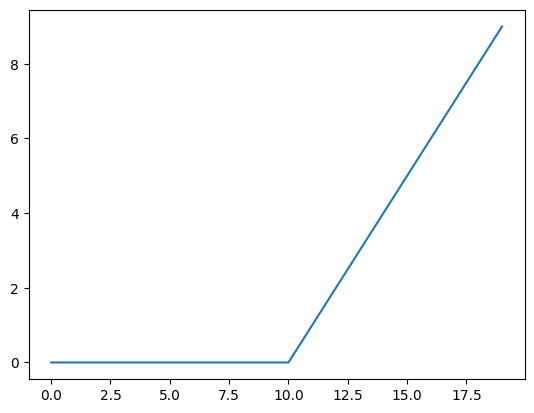

In [ ]:
plt.plot(torch.relu(A));

In [ ]:
def relu(x : torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x) #inputs must be tensors
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

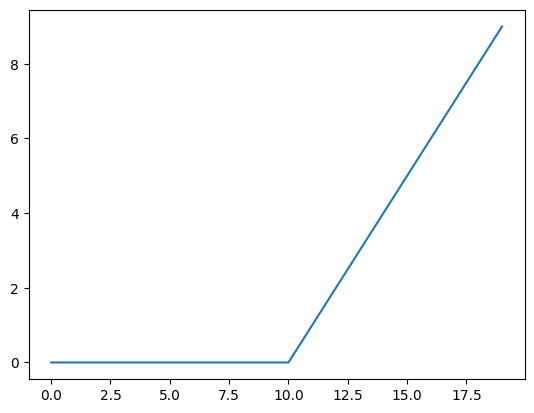

In [ ]:
plt.plot(relu(A));

In [ ]:
# For sigmoid
def sigmoid(X:torch.Tensor) -> torch.Tensor:
  return 1/ (1 + torch.exp(-X))

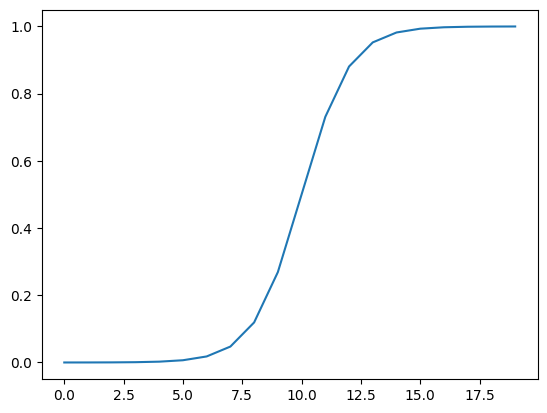

In [ ]:
plt.plot(torch.sigmoid(A));

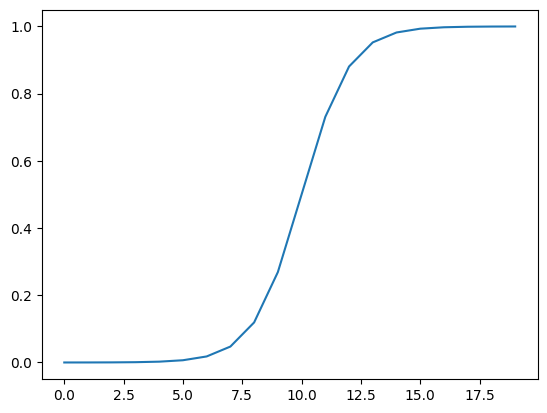

In [ ]:
plt.plot(sigmoid(A));

## 8. Putting it all together with a multi-class classification problem

* Binary Classification = one thing or another (cat vs dog, fraud vs not fraud etc)
* Multi-class Classification =  more than one thing or another(cat vs dog vs chicken)

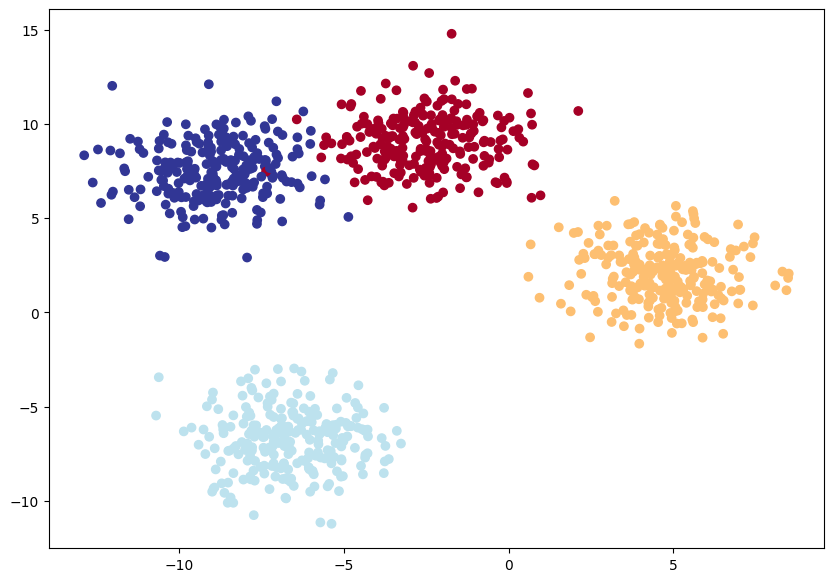

In [ ]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi class data
X_blob, y_blob = make_blobs(n_samples = 1000,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5,
                            random_state = RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# 3.
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size = 0.2,
                                                                        random_state = RANDOM_SEED)
# 4. Plot data (visualize)
plt.figure(figsize = (10,7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c = y_blob, cmap = plt.cm.RdYlBu);

### 8.2 Building a multiclass classification model in PyTorch

In [ ]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Build a multiclass classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units = 8):
    """ Initialize multi-class classification model.

    Args:
      input_features (int): Number of input features to the model.
      output_features (int): Number of output features of the model.
      hidden_units (int): Number of hidden units between layers, default 8.

      Returns:
        Pytorch model.
      Example:
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = output_features)
    )
  def forward(self, X):
    return self.linear_layer_stack(X)

# Create an instance of BlobModel and send it to target device
model_4 = BlobModel(input_features = 2,
                    output_features = 4,
                    hidden_units = 8).to(device)
model_4


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
torch.unique(y_blob_train)

tensor([0., 1., 2., 3.])

In [ ]:
### 8.3 Create a loss function and an optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_4.parameters(),
                             lr = 0.01)

### 8.4 Getting prediction probabilities for a multi class PyTorch model

* Getting raw outputs

* In order to evaluate and train and test our model, we need to convert our model's outputs (logits) to prediction probabilities and then to prediction labels.

Logits (Raw outputs) -> Pred probabilities -> Pred labels

In [ ]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))
y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0')

In [ ]:
# Random predictions
y_preds_prob = torch.softmax(y_logits, dim =1)
y_preds = torch.argmax(y_preds_prob, dim = 1)
y_preds_prob[:10], y_preds[:10]

(tensor([[0.3169, 0.3244, 0.1405, 0.2182],
         [0.3336, 0.1432, 0.2026, 0.3206],
         [0.3011, 0.1843, 0.2823, 0.2323],
         [0.3078, 0.2766, 0.1836, 0.2320],
         [0.3719, 0.1286, 0.1532, 0.3463],
         [0.3381, 0.1358, 0.1929, 0.3331],
         [0.2867, 0.1841, 0.2861, 0.2431],
         [0.3554, 0.1355, 0.1740, 0.3351],
         [0.3009, 0.1841, 0.2779, 0.2371],
         [0.3595, 0.1350, 0.1695, 0.3360]], device='cuda:0'),
 tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0'))

In [ ]:
torch.sum(y_preds_prob[0])

tensor(1., device='cuda:0')

In [ ]:
### 8.5 Creating a training and testing loop for multi-class PyTorch model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 200

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
  model_4.train()

  y_logits = model_4(X_blob_train).squeeze()
  y_preds = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

  loss = loss_fn(y_logits, y_blob_train.long())
  acc = accuracy_fn(y_blob_train, y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test).squeeze()
    test_preds = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

    test_loss = loss_fn(test_logits, y_blob_test.long())
    test_acc = accuracy_fn(y_blob_test, test_preds)

  if epoch % 20 == 0:
    print(f"Epoch : {epoch} | Loss : {loss:.4f} | Accuracy : {acc:.2f}% | Test_Loss : {test_loss:.4f} | Test_accuracy : {test_acc:.2f}%")

Epoch : 0 | Loss : 1.1588 | Accuracy : 40.38% | Test_Loss : 1.0978 | Test_accuracy : 46.50%
Epoch : 20 | Loss : 0.3818 | Accuracy : 98.00% | Test_Loss : 0.3698 | Test_accuracy : 99.00%
Epoch : 40 | Loss : 0.0462 | Accuracy : 99.25% | Test_Loss : 0.0384 | Test_accuracy : 99.50%
Epoch : 60 | Loss : 0.0269 | Accuracy : 99.25% | Test_Loss : 0.0176 | Test_accuracy : 99.50%
Epoch : 80 | Loss : 0.0246 | Accuracy : 99.12% | Test_Loss : 0.0145 | Test_accuracy : 99.50%
Epoch : 100 | Loss : 0.0236 | Accuracy : 99.38% | Test_Loss : 0.0130 | Test_accuracy : 99.50%
Epoch : 120 | Loss : 0.0230 | Accuracy : 99.38% | Test_Loss : 0.0122 | Test_accuracy : 99.50%
Epoch : 140 | Loss : 0.0226 | Accuracy : 99.50% | Test_Loss : 0.0115 | Test_accuracy : 99.50%
Epoch : 160 | Loss : 0.0221 | Accuracy : 99.50% | Test_Loss : 0.0110 | Test_accuracy : 99.50%
Epoch : 180 | Loss : 0.0217 | Accuracy : 99.50% | Test_Loss : 0.0105 | Test_accuracy : 99.50%


### 8.6 Making and evaluating predictions with a PyTorch multi-class model


In [ ]:
model_4.eval()
with torch.inference_mode():
  y_preds = torch.softmax(model_4(X_blob_test).squeeze(), dim = 1).argmax(dim=1)
y_preds[:10], y_blob_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0'),
 tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.], device='cuda:0'))

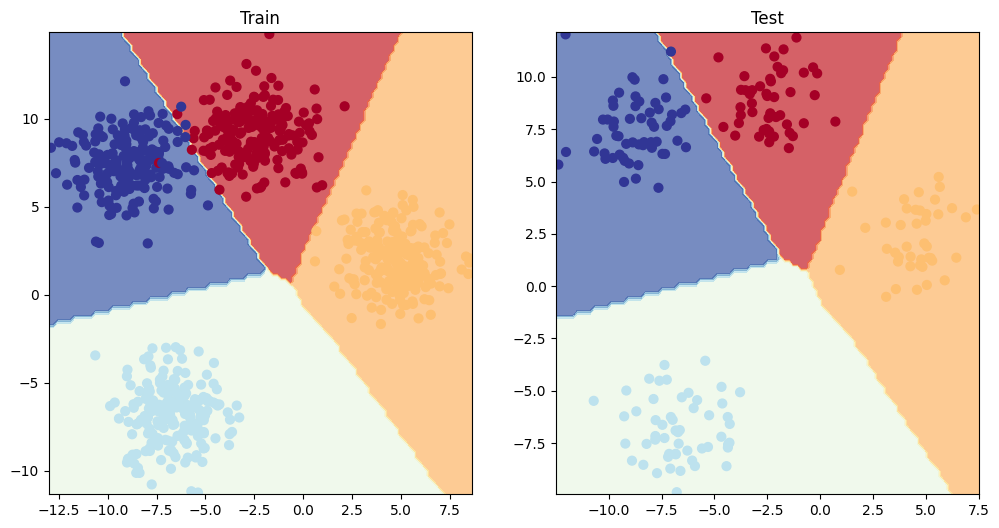

In [ ]:
# Plotting
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. A few more Classification metrics...(to evaluate our model)

tp = true positives, tn = true negatives, fp = false positives, fn = false negatives
Python Library -> torchmetrics.____

* **Accuracy** - Out of a 100 samples how may does our model get right?
formula = (tp + tn) / (tp + tn + fp + fn) => torchmetrics.Accuracy()

* Precision = tp / (tp + fp)

* Recall = tp / (tp + fn)

* F1-Score = 2 * (P * R) / (P + R)

* Confusion matrix = https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/

* Classification report = https://www.geeksforgeeks.org/machine-learning/compute-classification-report-and-confusion-matrix-in-python/

Precision Recall tradeoff = After a threshold as P dec R inc and vice versa.

In [ ]:
!pip install torchmetrics

In [ ]:
from torchmetrics import Accuracy
torchmetric_acc = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)
torchmetric_acc = torchmetric_acc(y_preds, y_blob_test)
torchmetric_acc

tensor(0.9950, device='cuda:0')

## Momentum based gradient descent
In the context of gradient optimization it refers to a method that smoothens the optimization trajectory by adding a term that helps the optimizer remember the past gradients.

https://www.geeksforgeeks.org/machine-learning/ml-momentum-based-gradient-optimizer-introduction/

## Notebook 01 : Exercises

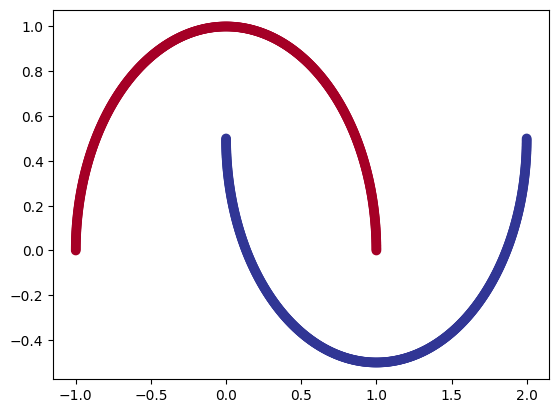

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

n = 1000
X, y = make_moons(n_samples = 1000,
                  noise = 0.0,
                  random_state = 42)
plt.scatter(X[:,0], X[:, 1], c = y, cmap = plt.cm.RdYlBu);

In [ ]:
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)
len(X_train), X_train.shape

(800, torch.Size([800, 2]))

In [ ]:
from torch import nn

class MoonModelV1(nn.Module):
  def __init__(self, inf, outf, hdu):
    super().__init__()

    self.layer_stack = nn.Sequential(
        nn.Linear(in_features = inf, out_features = hdu),
        nn.ReLU(),
        nn.Linear(in_features = hdu, out_features = hdu),
        nn.Tanh(),
        nn.Linear(in_features = hdu, out_features = outf)
    )
  def forward(self, X):
    return self.layer_stack(X)

model_5 = MoonModelV1(2, 1, 8).to(device)
model_5

MoonModelV1(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [ ]:
#Loss and optim
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(params = model_5.parameters(),
                             lr = 0.01)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 200

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_5.train()

  y_logits = model_5(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_5.eval()
  with torch.inference_mode():
    test_logits = model_5(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    t_acc = accuracy_fn(y_test, test_pred)

    if epoch % 10 == 0:
      print(f"Epoch : {epoch} | Loss : {loss:.4f} | Accuracy = {acc:.2f}% | Test Loss = {test_loss:.4f} | Accuracy : {t_acc:.2f}%")

Epoch : 0 | Loss : 0.7308 | Accuracy = 45.50% | Test Loss = 0.7125 | Accuracy : 42.00%
Epoch : 10 | Loss : 0.6340 | Accuracy = 84.75% | Test Loss = 0.6281 | Accuracy : 82.00%
Epoch : 20 | Loss : 0.4883 | Accuracy = 81.88% | Test Loss = 0.4909 | Accuracy : 77.00%
Epoch : 30 | Loss : 0.3634 | Accuracy = 83.62% | Test Loss = 0.3776 | Accuracy : 79.00%
Epoch : 40 | Loss : 0.2968 | Accuracy = 85.88% | Test Loss = 0.2996 | Accuracy : 85.50%
Epoch : 50 | Loss : 0.2528 | Accuracy = 88.75% | Test Loss = 0.2499 | Accuracy : 91.00%
Epoch : 60 | Loss : 0.2341 | Accuracy = 90.25% | Test Loss = 0.2300 | Accuracy : 92.00%
Epoch : 70 | Loss : 0.2161 | Accuracy = 90.62% | Test Loss = 0.2123 | Accuracy : 92.50%
Epoch : 80 | Loss : 0.1998 | Accuracy = 91.50% | Test Loss = 0.1968 | Accuracy : 92.00%
Epoch : 90 | Loss : 0.1795 | Accuracy = 92.50% | Test Loss = 0.1741 | Accuracy : 93.00%
Epoch : 100 | Loss : 0.1532 | Accuracy = 93.88% | Test Loss = 0.1459 | Accuracy : 94.50%
Epoch : 110 | Loss : 0.1219 | Ac

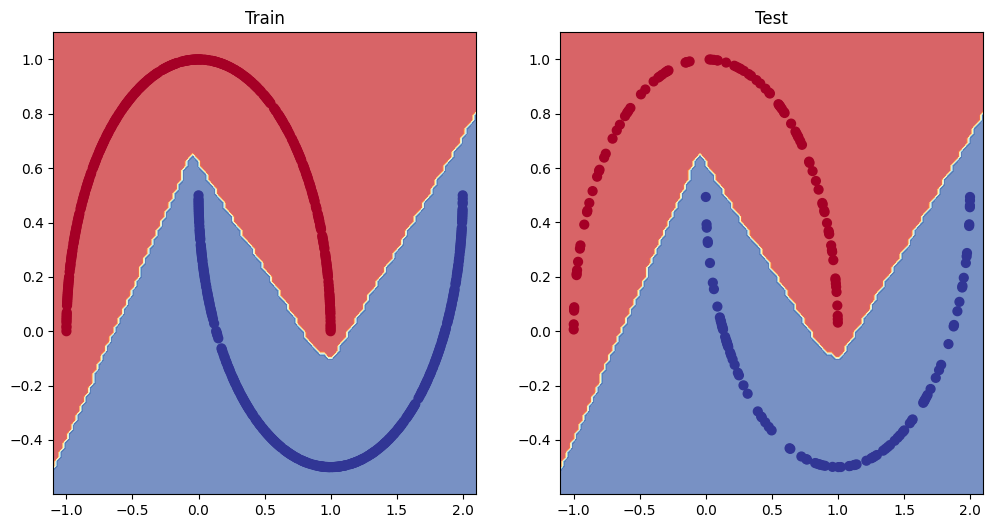

In [ ]:
plt.figure(figsize = (12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_5, X_train, y_train);
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_5, X_test, y_test);

In [ ]:
def tanh_function(X):
  return (torch.exp(X) - torch.exp(-X))/ (torch.exp(X) + torch.exp(-X))

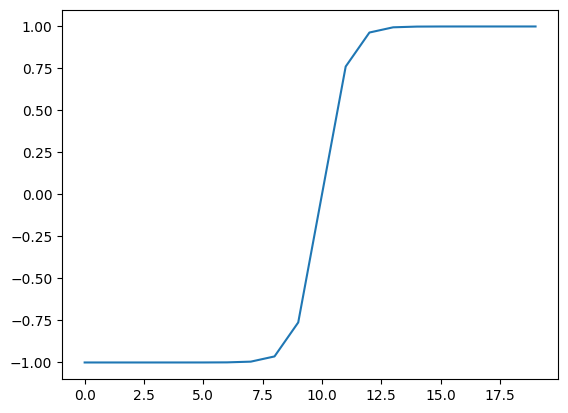

In [ ]:
plt.plot(torch.tanh(A));

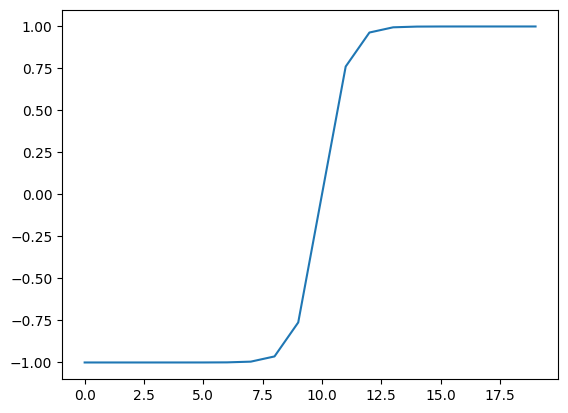

In [ ]:
plt.plot(tanh_function(A));

## Multiclass Model

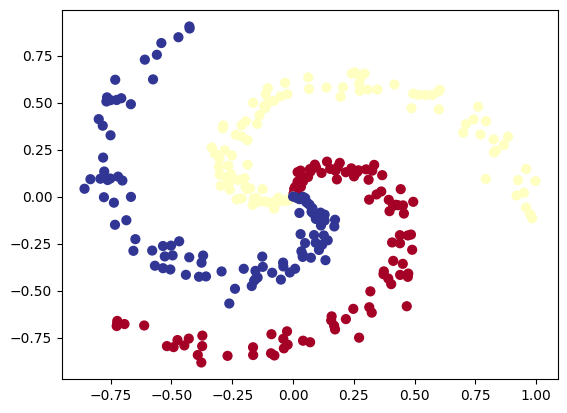

In [ ]:
# Spiral dataset creation

import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes

np.random.seed(42)

X = np.zeros((N*K, D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels

for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [ ]:
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
len(X_train), len(X_test), len(y_train), len(y_test)

(240, 60, 240, 60)

In [ ]:
class SpiralModelV1(nn.Module):
  def __init__(self, inf, outf, hdu):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Linear(in_features = inf, out_features = hdu),
        nn.ReLU(),
        nn.Linear(in_features = hdu, out_features = hdu),
        nn.ReLU(),
        nn.Linear(in_features = hdu, out_features = outf)
    )
  def forward(self, X):
    return self.layer_stack(X)

model_6 = SpiralModelV1(2, 3, 8).to(device)
model_6

SpiralModelV1(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)

In [ ]:
from torchmetrics import Accuracy
accuracy_fn = Accuracy(task = 'multiclass', num_classes = 3).to(device)

In [ ]:
loss_f = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_6.parameters(),
                             lr = 0.02)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_6.train()

  y_logits = model_6(X_train).squeeze()
  y_preds = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

  loss = loss_f(y_logits, y_train.long())
  acc = accuracy_fn(y_train, y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_6.eval()
  with torch.inference_mode():
    test_logits = model_6(X_test).squeeze()
    test_preds = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

    test_loss = loss_f(test_logits, y_test.long())
    test_acc = accuracy_fn(y_test, test_preds)

    if epoch % 100 == 0:
      print(f"Epoch : {epoch} | Loss : {loss:.4f} | Accuracy : {acc:.2f} | Test Loss : {test_loss:.4f} | Test Accuracy = {test_acc:.2f}")

Epoch : 0 | Loss : 1.1024 | Accuracy : 0.32 | Test Loss : 1.0820 | Test Accuracy = 0.40
Epoch : 100 | Loss : 0.1020 | Accuracy : 0.98 | Test Loss : 0.0726 | Test Accuracy = 1.00
Epoch : 200 | Loss : 0.0396 | Accuracy : 0.99 | Test Loss : 0.0124 | Test Accuracy = 1.00
Epoch : 300 | Loss : 0.0281 | Accuracy : 0.99 | Test Loss : 0.0035 | Test Accuracy = 1.00
Epoch : 400 | Loss : 0.0230 | Accuracy : 0.99 | Test Loss : 0.0014 | Test Accuracy = 1.00
Epoch : 500 | Loss : 0.0202 | Accuracy : 0.99 | Test Loss : 0.0008 | Test Accuracy = 1.00
Epoch : 600 | Loss : 0.0185 | Accuracy : 0.99 | Test Loss : 0.0004 | Test Accuracy = 1.00
Epoch : 700 | Loss : 0.0173 | Accuracy : 0.99 | Test Loss : 0.0003 | Test Accuracy = 1.00
Epoch : 800 | Loss : 0.0165 | Accuracy : 0.99 | Test Loss : 0.0003 | Test Accuracy = 1.00
Epoch : 900 | Loss : 0.0159 | Accuracy : 0.99 | Test Loss : 0.0003 | Test Accuracy = 1.00


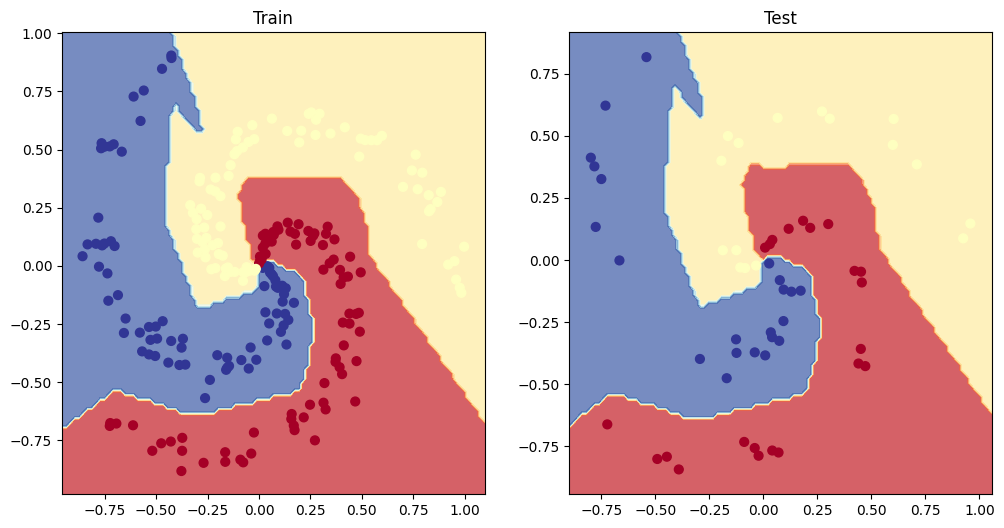

In [ ]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_6, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_6, X_test, y_test)